In [1]:
import sys
!{sys.executable} -m pip install torch
!{sys.executable} -m pip install blobfile
!{sys.executable} -m pip install transformer_lens
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install lxml



In [2]:
import torch
import blobfile as bf
import transformer_lens
import sparse_autoencoder
import numpy as np
import matplotlib.pyplot as plt
# Import the model
model = transformer_lens.HookedTransformer.from_pretrained("gpt2", center_writing_weights=False)
device = next(model.parameters()).device


layer_index = 8
location = "resid_post_mlp"

transformer_lens_loc = {
    "mlp_post_act": f"blocks.{layer_index}.mlp.hook_post",
    "resid_delta_attn": f"blocks.{layer_index}.hook_attn_out",
    "resid_post_attn": f"blocks.{layer_index}.hook_resid_mid",
    "resid_delta_mlp": f"blocks.{layer_index}.hook_mlp_out",
    "resid_post_mlp": f"blocks.{layer_index}.hook_resid_post",
}[location]
# load the autoencoder
with bf.BlobFile(sparse_autoencoder.paths.v5_32k(location, layer_index), mode="rb") as f:
    state_dict = torch.load(f)
    autoencoder = sparse_autoencoder.Autoencoder.from_state_dict(state_dict)
    autoencoder.to(device)


# Add the NTK computation for transformer models with averaged token cross entropy loss
def compute_transformer_ntk(
    model,
    prompts,
    device=None
):
    """
    Compute the empirical NTK for a transformer model based on prompt-level loss,
    summing the losses for each token in the prompt.
    
    Args:
        model: The transformer model (transformer_lens HookedTransformer)
        prompts: List of text prompts
        device: Device to run computation on
        
    Returns:
        NTK matrix of shape (num_prompts, num_prompts)
    """
    if device is None:
        device = next(model.parameters()).device
    
    # Get the model parameters we care about
    parameters = [p for p in model.parameters() if p.requires_grad]
    n_params = sum(p.numel() for p in parameters)
    n_samples = len(prompts)
    
    # Initialize Jacobian - one row per prompt, one column per parameter
    jacobian = torch.zeros(n_samples, n_params, device=device)
    
    for i, prompt in enumerate(prompts):
        print(f"Processing prompt {i+1} of {n_samples}")
        # Tokenize the prompt with an offset for calculating loss
        tokens = model.to_tokens(prompt, prepend_bos=True).to(device)
        
        # Target tokens are the input tokens shifted right 
        # (for standard language modeling loss where we predict the next token)
        input_tokens = tokens[:, :-1]  # All tokens except the last one
        target_tokens = tokens[:, 1:]  # All tokens except the first one
        
        # Zero gradients before computation
        model.zero_grad()
        
        # Forward pass to get logits
        logits = model(input_tokens)
        
        # Compute loss - sum the cross-entropy loss for all tokens
        loss_fn = torch.nn.CrossEntropyLoss(reduction='mean')
        loss = loss_fn(logits.reshape(-1, logits.size(-1)), target_tokens.reshape(-1))
        loss = loss / len(tokens[0])
        # Compute gradient of loss with respect to model parameters
        loss.backward()
        
        # Extract gradients
        idx = 0
        for param in parameters:
            if param.grad is not None:
                grad_flatten = param.grad.flatten()
                jacobian[i, idx:idx+len(grad_flatten)] = grad_flatten
                idx += len(grad_flatten)
            else:
                # Some parameters might not be part of the computation graph
                idx += param.numel()
    
    # Compute the NTK matrix: K(x, x') = J(x) · J(x')^T
    ntk_matrix = jacobian @ jacobian.T
    return ntk_matrix.detach().cpu().numpy()

# --- Utility: Normalize a Matrix ---
def normalize_matrix(M: np.ndarray):
    M_tensor = torch.tensor(M, device=device)
    diag = torch.sqrt(torch.diag(M_tensor))
    norm_matrix = M_tensor / (diag.unsqueeze(1) * diag.unsqueeze(0) + 1e-8)
    return norm_matrix.detach().cpu().numpy()

/Users/muratcubuktepe/Desktop/Coding/python_envs/AST-reproduce-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded pretrained model gpt2 into HookedTransformer


In [3]:
# Sample list of prompts
test_prompts = [
    # Pair 1: Quantum physics (short and long)
    "Quantum entanglement connects particles across any distance.",
    "The phenomenon of quantum entanglement allows particles to be instantly connected regardless of the distance separating them, meaning that actions performed on one particle can immediately affect another, a concept Einstein famously referred to as 'spooky action at a distance.'",
    
    # Pair 2: Renaissance art (short and long)
    "Michelangelo's Sistine Chapel showcases masterful human anatomy.",
    "Michelangelo's Sistine Chapel ceiling demonstrates his exceptional understanding of human anatomy, featuring over 300 figures painted in dynamic poses that reveal his knowledge of musculature and his ability to depict the human form from multiple perspectives and in various states of tension.",
    
    # Pair 3: Climate change (short and long)
    "Rising global temperatures are melting glaciers rapidly.",
    "Rising global temperatures caused by greenhouse gas emissions are accelerating glacial melt worldwide, with some glaciers losing over 30 meters of thickness annually, contributing to sea level rise and threatening freshwater supplies for millions of people who depend on glacial runoff.",
    
    # Pair 4: Space exploration (short and long)
    "The James Webb Telescope observes distant galaxies in infrared.",
    "The James Webb Space Telescope uses advanced infrared technology to observe extremely distant galaxies that formed during the universe's early development, penetrating cosmic dust clouds and detecting light that has been traveling for over 13 billion years, offering unprecedented insights into cosmic evolution.",
    
    # Pair 5: Artificial intelligence (short and long)
    "Large language models can generate coherent text.",
    "Large language models trained on trillions of words can generate remarkably coherent and contextually appropriate text by predicting probable word sequences, utilizing attention mechanisms to maintain topic relevance and syntactic consistency across thousands of tokens without explicit programming of grammar rules.",
    
    # Pair 6: Medieval history (short and long)
    "The Crusades were religious wars to reclaim the Holy Land.",
    "The Crusades were a series of eight major religious military campaigns conducted between 1096 and 1291, initiated by various popes and European monarchs to reclaim Jerusalem and other sites considered holy by Christians from Islamic rule, resulting in significant cultural exchange between East and West despite their violent nature.",
    
    # Pair 7: Culinary arts (short and long)
    "French cuisine emphasizes precise techniques and sauces.",
    "French cuisine is distinguished by its rigorous emphasis on precise cooking techniques, standardized methods, and the systematic approach to sauce-making developed by Auguste Escoffier, featuring the five mother sauces (béchamel, velouté, espagnole, hollandaise, and tomato) that form the foundation of countless classic French dishes."
]

In [4]:
# Ensure model is in evaluation mode but allows gradient computation
model.eval()
for param in model.parameters():
    param.requires_grad = True

# Compute the NTK matrix
ntk_matrix = compute_transformer_ntk(
    model=model,
    prompts=test_prompts
)




Processing prompt 1 of 14
Processing prompt 2 of 14
Processing prompt 3 of 14
Processing prompt 4 of 14
Processing prompt 5 of 14
Processing prompt 6 of 14
Processing prompt 7 of 14
Processing prompt 8 of 14
Processing prompt 9 of 14
Processing prompt 10 of 14
Processing prompt 11 of 14
Processing prompt 12 of 14
Processing prompt 13 of 14
Processing prompt 14 of 14


In [5]:
# Get the number of features from the autoencoder's decoder weights
num_features = autoencoder.decoder.weight.shape[1]
num_activations = autoencoder.decoder.weight.shape[0]
# Initialize dicts for raw activations and features
model_activations_matrix = {}
model_features_matrix = {}
# Initialize matrices for aggregated activations and features
sae_aggregation_matrix = torch.zeros(len(test_prompts), num_features, device=device)
activation_aggregation_matrix = torch.zeros(len(test_prompts), num_activations, device=device)

In [6]:
for i, prompt in enumerate(test_prompts):
    print(f"Processing prompt {i+1} of {len(test_prompts)}")
    tokens = model.to_tokens(prompt)  # (1, n_tokens)
    with torch.no_grad():
        logits, activation_cache = model.run_with_cache(tokens, remove_batch_dim=True)

    input_tensor = activation_cache[transformer_lens_loc]
    
    # Process all tokens in the prompt
    with torch.no_grad():
        latent_activations, info = autoencoder.encode(input_tensor)
        
        model_activations_matrix[i] = input_tensor
        model_features_matrix[i] = latent_activations

Processing prompt 1 of 14
Processing prompt 2 of 14
Processing prompt 3 of 14
Processing prompt 4 of 14
Processing prompt 5 of 14
Processing prompt 6 of 14
Processing prompt 7 of 14
Processing prompt 8 of 14
Processing prompt 9 of 14
Processing prompt 10 of 14
Processing prompt 11 of 14
Processing prompt 12 of 14
Processing prompt 13 of 14
Processing prompt 14 of 14


In [7]:
def plot_matrix(normalized_ntk_matrix, normalized_sae_graph, normalized_activation_aggregation_graph, title):
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    # Find global min and max values across both matrices for consistent coloring
    global_min = min(normalized_ntk_matrix.min(), normalized_sae_graph.min())
    global_max = max(normalized_ntk_matrix.max(), normalized_sae_graph.max())
    
    # Use the same colormap for both plots
    cmap = 'viridis'
    
    # Plot NTK Matrix with shared range
    im1 = ax1.imshow(normalized_ntk_matrix, cmap=cmap, vmin=global_min, vmax=global_max)
    ax1.set_title('Normalized NTK Matrix')
    
    # Add text annotations with values
    for i in range(normalized_ntk_matrix.shape[0]):
        for j in range(normalized_ntk_matrix.shape[1]):
            value = normalized_ntk_matrix[i, j]
            # Adjust text color based on middle of range
            color = 'white' if value < (global_min + global_max)/2 else 'black'
            ax1.text(j, i, f'{value:.2f}', ha='center', va='center', 
                    color=color, fontsize=8)
    
    # Create a colorbar with the shared range
    cbar1 = plt.colorbar(im1, ax=ax1)
    
    # Plot Latent Activations Matrix with same shared range
    im3 = ax3.imshow(normalized_activation_aggregation_graph, cmap=cmap, vmin=global_min, vmax=global_max)
    ax3.set_title('Normalized Activation Aggregation Matrix')
    
    # Create a colorbar with the shared range
    cbar3 = plt.colorbar(im3, ax=ax3)
    # Add text annotations with values
    for i in range(normalized_activation_aggregation_graph.shape[0]):
        for j in range(normalized_activation_aggregation_graph.shape[1]):
            value = normalized_activation_aggregation_graph[i, j]
            # Adjust text color based on middle of range
            color = 'white' if value < (global_min + global_max)/2 else 'black'
            ax3.text(j, i, f'{value:.2f}', ha='center', va='center', 
                    color=color, fontsize=8)
    
    # Plot SAE Matrix with same shared range
    im2 = ax2.imshow(normalized_sae_graph, cmap=cmap, vmin=global_min, vmax=global_max)
    ax2.set_title('Normalized SAE Matrix')
    
    # Add text annotations with values
    for i in range(normalized_sae_graph.shape[0]):
        for j in range(normalized_sae_graph.shape[1]):
            value = normalized_sae_graph[i, j]
            # Adjust text color based on middle of range
            color = 'white' if value < (global_min + global_max)/2 else 'black'
            ax2.text(j, i, f'{value:.2f}', ha='center', va='center', 
                    color=color, fontsize=8)
    
    # Create a colorbar with the shared range
    cbar2 = plt.colorbar(im2, ax=ax2)
    
    # Add labels for reference
    prompt_labels = [f"Prompt {i+1}" for i in range(len(test_prompts))]
    
    # Set ticks and labels for NTK matrix
    ax1.set_xticks(np.arange(len(prompt_labels)))
    ax1.set_yticks(np.arange(len(prompt_labels)))
    ax1.set_xticklabels(prompt_labels)
    ax1.set_yticklabels(prompt_labels)
    plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Set ticks and labels for SAE matrix
    ax2.set_xticks(np.arange(len(prompt_labels)))
    ax2.set_yticks(np.arange(len(prompt_labels)))
    ax2.set_xticklabels(prompt_labels)
    ax2.set_yticklabels(prompt_labels)
    plt.setp(ax2.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    

     # Add a global title to the figure
    fig.suptitle(title, fontsize=16, y=0.98)
    
    # Adjust the layout to make room for the title
    plt.tight_layout(rect=[0, 0.03, 1, 0.93])  # Adjusted top margin for the title
    plt.show()  


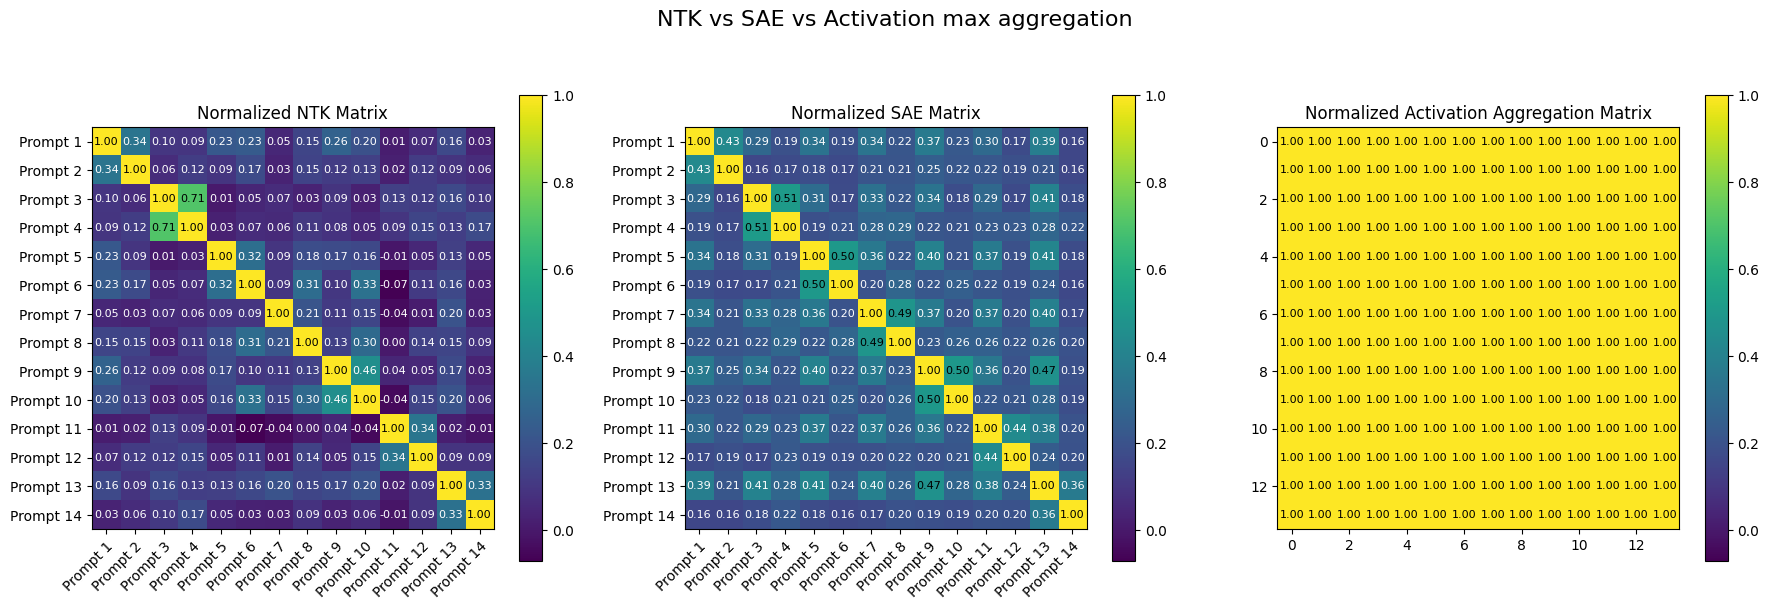

In [8]:
for i, prompt in enumerate(test_prompts):
    sae_aggregation_matrix[i] = model_features_matrix[i].amax(dim=0)
    activation_aggregation_matrix[i] = model_activations_matrix[i].amax(dim=0)
    
# Compute the SAE dependency graph (similarity matrix between prompts)
sae_dependency_graph = (sae_aggregation_matrix @ sae_aggregation_matrix.T).cpu().numpy()
activation_aggregation_dependency_graph = (activation_aggregation_matrix @ activation_aggregation_matrix.T).cpu().numpy()
normalized_sae_graph = normalize_matrix(sae_dependency_graph)
normalized_ntk_matrix = normalize_matrix(ntk_matrix)
normalized_activation_aggregation_graph = normalize_matrix(activation_aggregation_dependency_graph)

plot_matrix(normalized_ntk_matrix, normalized_sae_graph, normalized_activation_aggregation_graph, "NTK vs SAE vs Activation max aggregation")



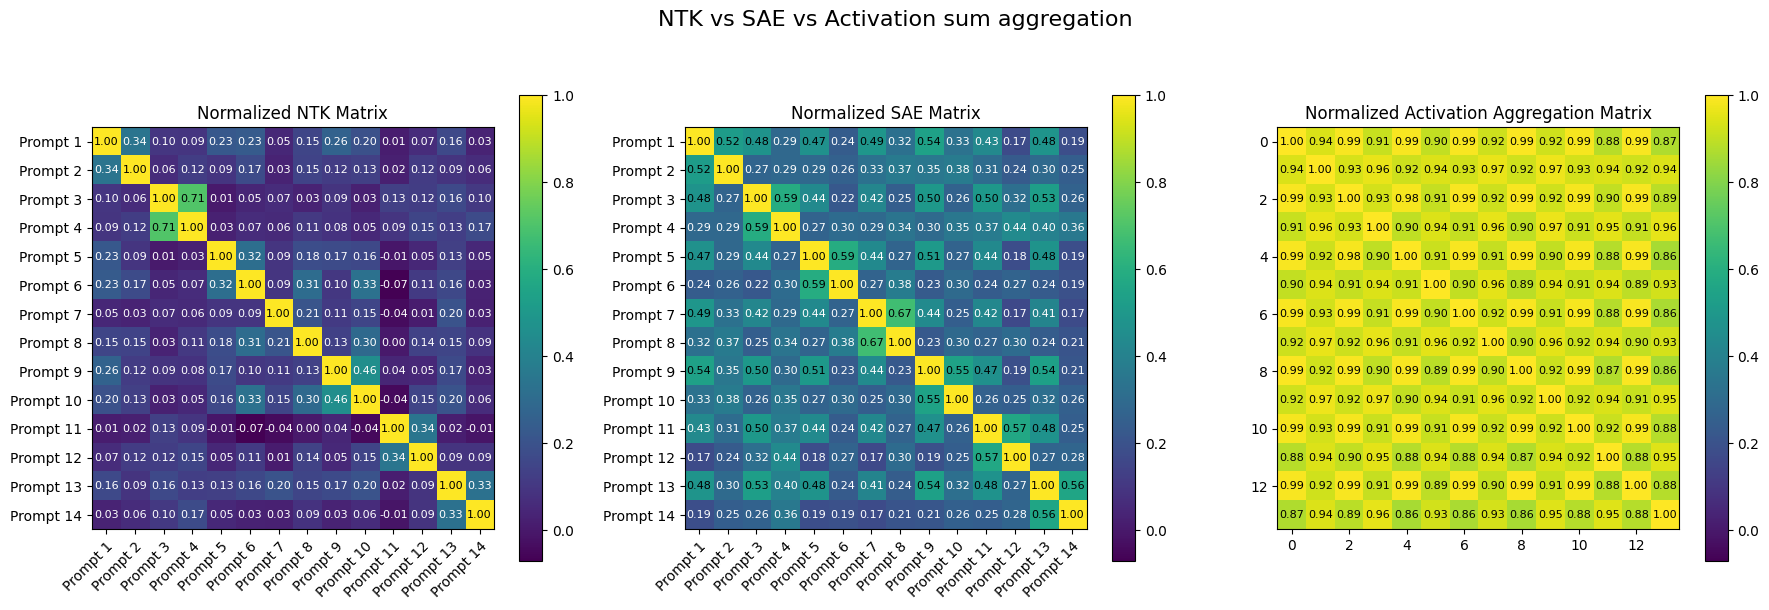

In [9]:
for i, prompt in enumerate(test_prompts):
    sae_aggregation_matrix[i] = model_features_matrix[i].sum(dim=0)
    activation_aggregation_matrix[i] = model_activations_matrix[i].sum(dim=0)
    
# Compute the SAE dependency graph (similarity matrix between prompts)
sae_dependency_graph = (sae_aggregation_matrix @ sae_aggregation_matrix.T).cpu().numpy()
activation_aggregation_dependency_graph = (activation_aggregation_matrix @ activation_aggregation_matrix.T).cpu().numpy()
normalized_sae_graph = normalize_matrix(sae_dependency_graph)
normalized_ntk_matrix = normalize_matrix(ntk_matrix)
normalized_activation_aggregation_graph = normalize_matrix(activation_aggregation_dependency_graph)

plot_matrix(normalized_ntk_matrix, normalized_sae_graph, normalized_activation_aggregation_graph, "NTK vs SAE vs Activation sum aggregation")



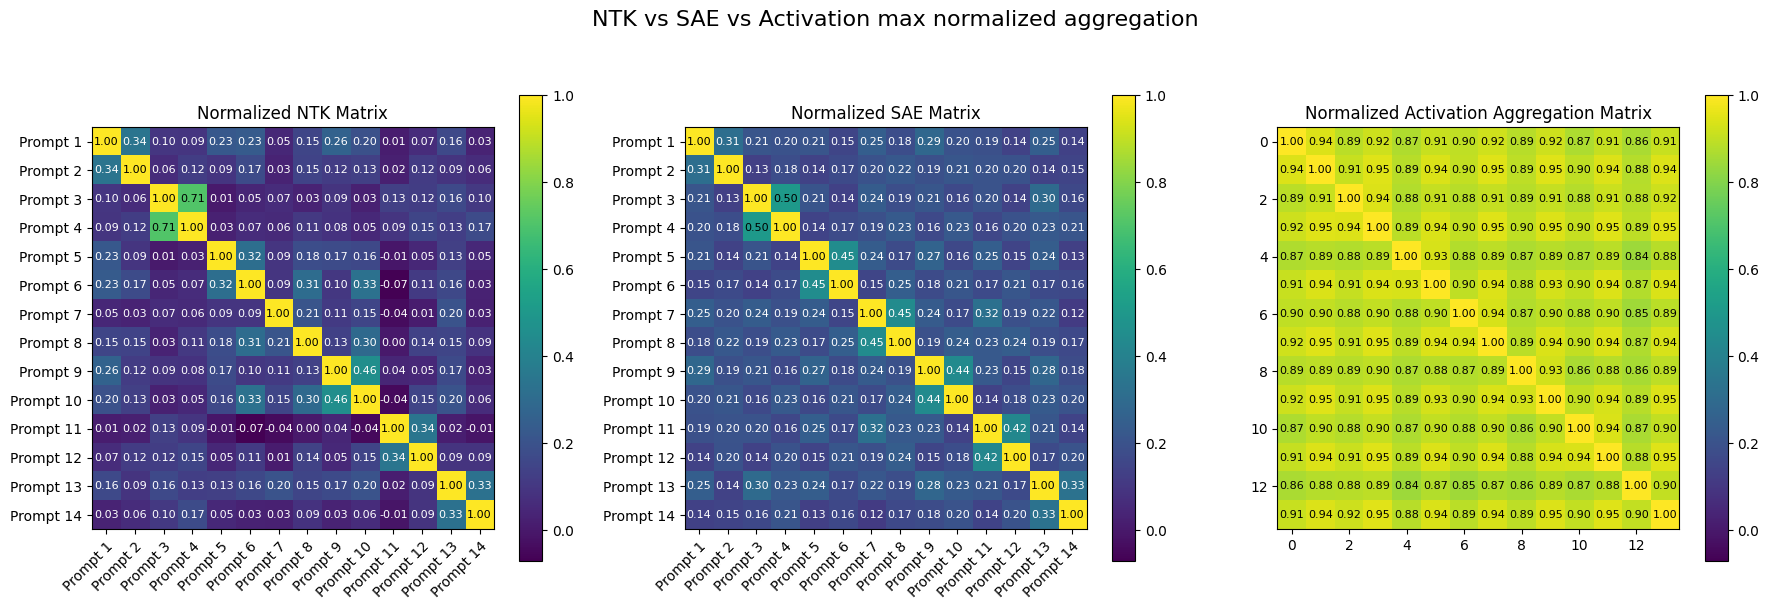

In [10]:
for i, prompt in enumerate(test_prompts):
    sae_aggregation_matrix[i] = torch.nn.functional.normalize(model_features_matrix[i], p=2, dim=0).amax(dim=0)
    activation_aggregation_matrix[i] = torch.nn.functional.normalize(model_activations_matrix[i], p=2, dim=0).amax(dim=0)
    
# Compute the SAE dependency graph (similarity matrix between prompts)
sae_dependency_graph = (sae_aggregation_matrix @ sae_aggregation_matrix.T).cpu().numpy()
activation_aggregation_dependency_graph = (activation_aggregation_matrix @ activation_aggregation_matrix.T).cpu().numpy()
normalized_sae_graph = normalize_matrix(sae_dependency_graph)
normalized_ntk_matrix = normalize_matrix(ntk_matrix)
normalized_activation_aggregation_graph = normalize_matrix(activation_aggregation_dependency_graph)

plot_matrix(normalized_ntk_matrix, normalized_sae_graph, normalized_activation_aggregation_graph, "NTK vs SAE vs Activation max normalized aggregation")



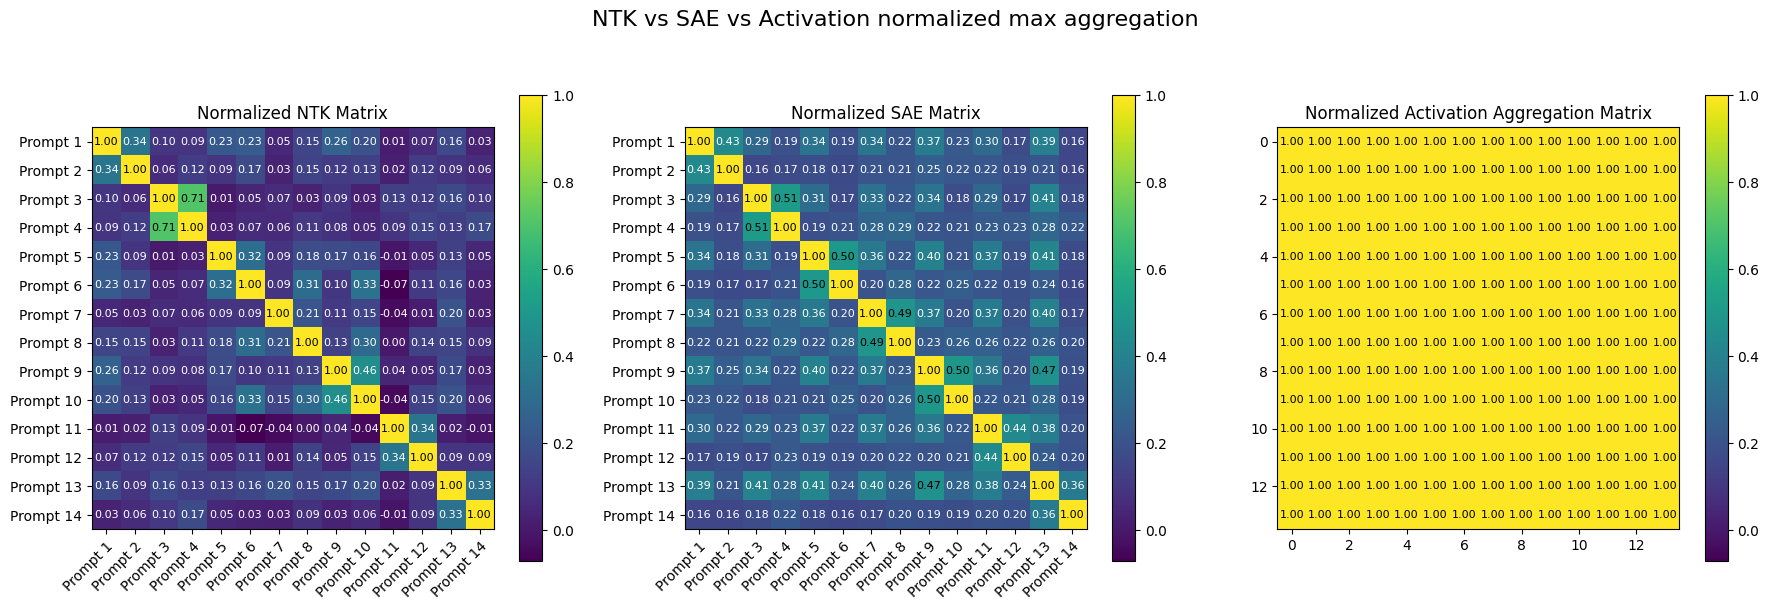

In [11]:
for i, prompt in enumerate(test_prompts):
    sae_aggregation_matrix[i] = torch.nn.functional.normalize(model_features_matrix[i].amax(dim=0), p=2, dim=0)
    activation_aggregation_matrix[i] = torch.nn.functional.normalize(model_activations_matrix[i].amax(dim=0), p=2, dim=0)
    
# Compute the SAE dependency graph (similarity matrix between prompts)
sae_dependency_graph = (sae_aggregation_matrix @ sae_aggregation_matrix.T).cpu().numpy()
activation_aggregation_dependency_graph = (activation_aggregation_matrix @ activation_aggregation_matrix.T).cpu().numpy()
normalized_sae_graph = normalize_matrix(sae_dependency_graph)
normalized_ntk_matrix = normalize_matrix(ntk_matrix)
normalized_activation_aggregation_graph = normalize_matrix(activation_aggregation_dependency_graph)

plot_matrix(normalized_ntk_matrix, normalized_sae_graph, normalized_activation_aggregation_graph, "NTK vs SAE vs Activation normalized max aggregation")



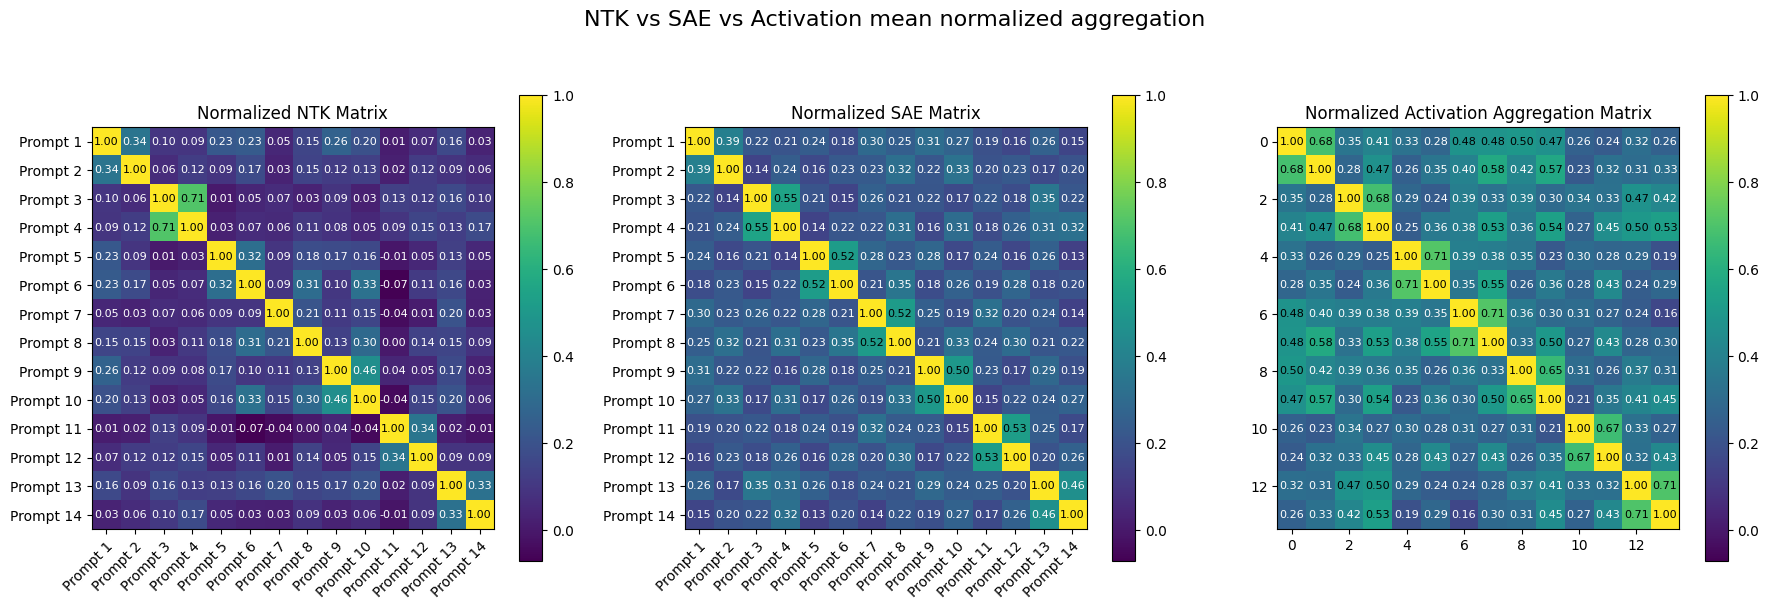

In [12]:
for i, prompt in enumerate(test_prompts):
    sae_aggregation_matrix[i] = torch.nn.functional.normalize(model_features_matrix[i], p=2, dim=0).mean(dim=0)
    activation_aggregation_matrix[i] = torch.nn.functional.normalize(model_activations_matrix[i], p=2, dim=0).mean(dim=0)
    
# Compute the SAE dependency graph (similarity matrix between prompts)
sae_dependency_graph = (sae_aggregation_matrix @ sae_aggregation_matrix.T).cpu().numpy()
activation_aggregation_dependency_graph = (activation_aggregation_matrix @ activation_aggregation_matrix.T).cpu().numpy()
normalized_sae_graph = normalize_matrix(sae_dependency_graph)
normalized_ntk_matrix = normalize_matrix(ntk_matrix)
normalized_activation_aggregation_graph = normalize_matrix(activation_aggregation_dependency_graph)

plot_matrix(normalized_ntk_matrix, normalized_sae_graph, normalized_activation_aggregation_graph, "NTK vs SAE vs Activation mean normalized aggregation")



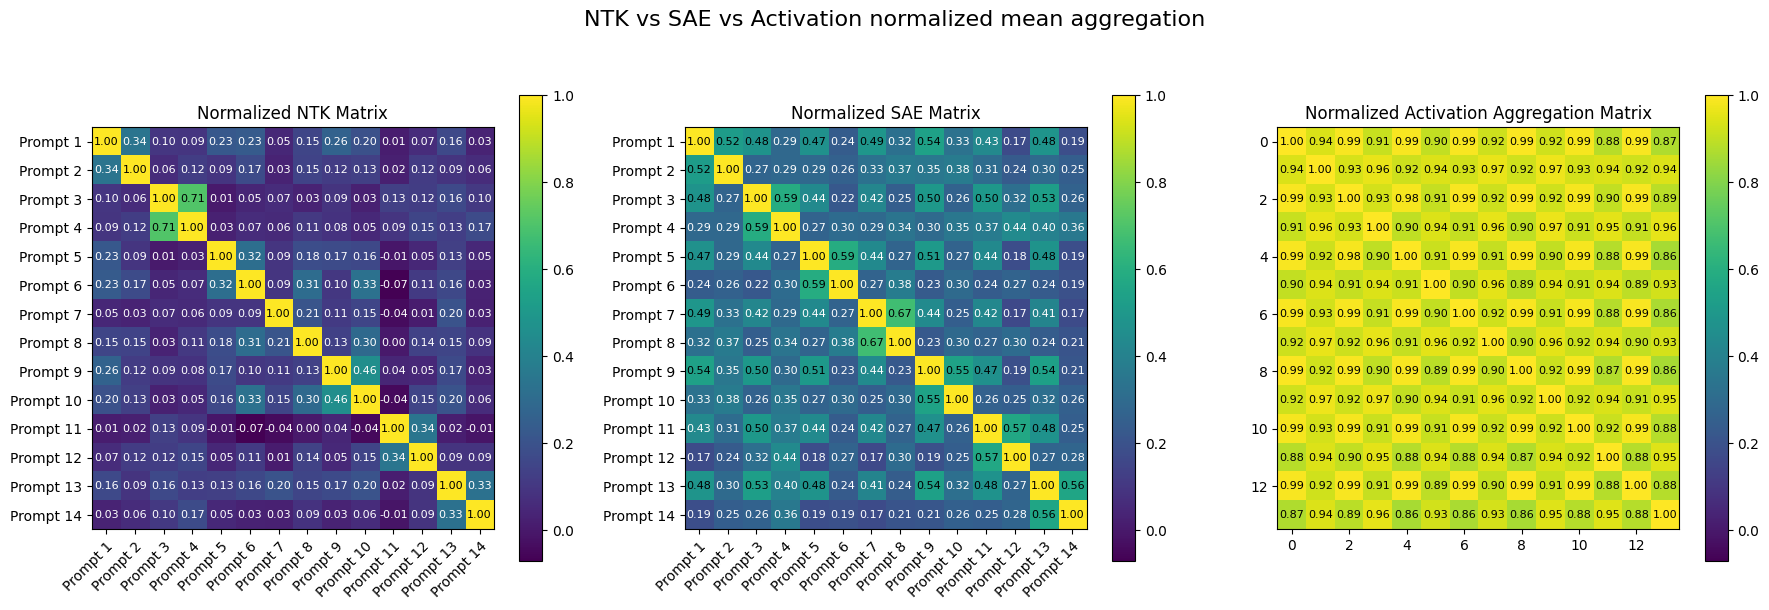

In [13]:
for i, prompt in enumerate(test_prompts):
    sae_aggregation_matrix[i] = torch.nn.functional.normalize(model_features_matrix[i].mean(dim=0), p=2, dim=0)
    activation_aggregation_matrix[i] = torch.nn.functional.normalize(model_activations_matrix[i].mean(dim=0), p=2, dim=0)
    
# Compute the SAE dependency graph (similarity matrix between prompts)
sae_dependency_graph = (sae_aggregation_matrix @ sae_aggregation_matrix.T).cpu().numpy()
activation_aggregation_dependency_graph = (activation_aggregation_matrix @ activation_aggregation_matrix.T).cpu().numpy()
normalized_sae_graph = normalize_matrix(sae_dependency_graph)
normalized_ntk_matrix = normalize_matrix(ntk_matrix)
normalized_activation_aggregation_graph = normalize_matrix(activation_aggregation_dependency_graph)

plot_matrix(normalized_ntk_matrix, normalized_sae_graph, normalized_activation_aggregation_graph, "NTK vs SAE vs Activation normalized mean aggregation")

